In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [76]:
df = pd.read_csv("data/height-weight.csv")

In [77]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


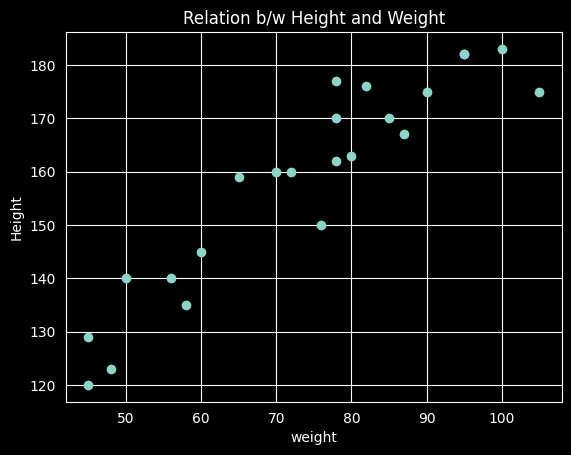

In [78]:
#scatter plot
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("weight")
plt.ylabel("Height")
plt.title("Relation b/w Height and Weight")

In [79]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


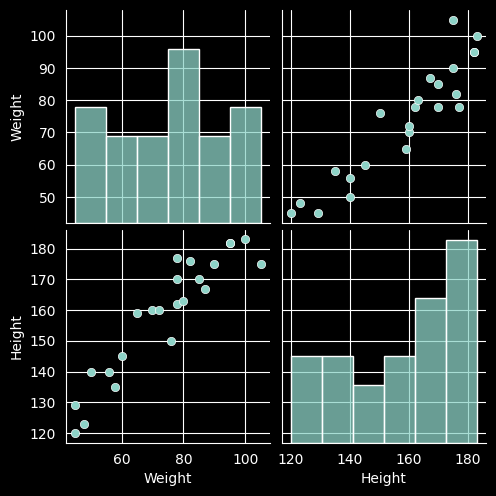

In [80]:
sns.pairplot(df)

In [81]:
# independent and dependent features
X = df[["Weight"]] ## independent features should be in dataframe or 2D array use [["weight"]]
Y = df["Height"] # this should be in 1D array no [[Height]]
np.array(X).shape


(23, 1)

In [82]:
#forbiden to use like this should use the previous one no [["wieght"]] 1D
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [83]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [84]:
#stanterdization
from sklearn.preprocessing import StandardScaler

In [85]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)

In [86]:
x_test = scalar.transform(x_test)

In [87]:
#Applay simple linear regression model
from sklearn.linear_model import LinearRegression

In [88]:
regression = LinearRegression(n_jobs=-1)

In [89]:
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:
# y = b0(intercept)+b1(coeff)xi
regression.coef_

array([17.2982057])

In [91]:
regression.intercept_

np.float64(156.47058823529412)

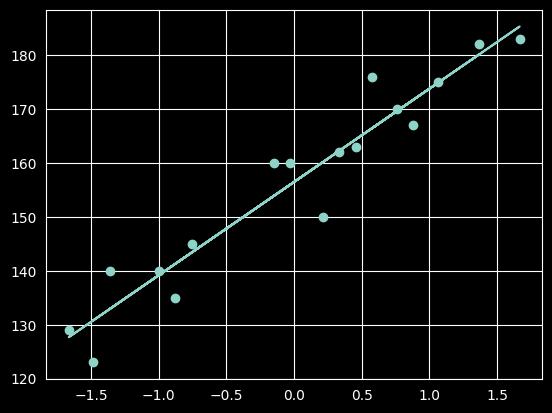

In [92]:
## plot training best fit line
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [93]:
#prediction for test data
y_pred = regression.predict(x_test)

In [95]:
# performance metrics
from sklearn.metrics import  mean_squared_error,mean_absolute_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse,mae,rmse)

114.84069295228699 9.66512588679501 10.716374991212605


In [96]:
from sklearn.metrics import  r2_score


In [97]:
r2_score = r2_score(y_test,y_pred)

In [98]:
r2_score

0.7360826717981276

# OLS Linear reggression

In [101]:
import statsmodels.api as sm

In [102]:
model = sm.OLS(y_train,x_train).fit()

In [105]:
predict = model.predict(x_test)

In [106]:
print(predict)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [108]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 28 Feb 2026   Prob (F-statistic):                       0.664
Time:                        12:59:49   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [110]:
#prediction for new data
regression.predict(scalar.transform([[72]]))

array([155.97744705])